# MNIST con PyTorch. Red Neuronal Feedforward

Implementación de una red neuronal feedforward para clasificación multiclase del dataset MNIST usando PyTorch.

## 1. Carga del dataset MNIST

In [1]:
import torch
from torch.utils.data import random_split
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

# Transformación: convierte imágenes PIL a tensores y normaliza píxeles a [0, 1]
transform = transforms.ToTensor()

# MNIST viene con 60,000 para train y 10,000 para test
full_train_dataset = datasets.MNIST(root='../data', train=True,  download=True, transform=transform)
test_dataset       = datasets.MNIST(root='../data', train=False, download=True, transform=transform)

# 10,000 muestras del train para validación
train_dataset, val_dataset = random_split(full_train_dataset, [50_000, 10_000])

print(f"Train:      {len(train_dataset):,} muestras")
print(f"Validación: {len(val_dataset):,} muestras")
print(f"Test:       {len(test_dataset):,} muestras")

Usando: cuda
Train:      50,000 muestras
Validación: 10,000 muestras
Test:       10,000 muestras


## 2. Definición de la red neuronal

In [2]:
class FeedForwardNet(nn.Module):
    """    
    Como parámetro se recibe una lista con el número de neuronas por capa oculta

    Arquitectura: Entrada (784) → [Linear → ReLU] x n_capas → Output (10)
    """
    def __init__(self, hidden_sizes: list[int]):
        super().__init__()
        
        layer_sizes = [784] + hidden_sizes + [10]
        
        layers = []
        for i in range(len(layer_sizes) - 1):
            # Añadir capas lineales y ReLU
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1])) 
            if i < len(layer_sizes) - 2:   # No ReLU en la última capa
                layers.append(nn.ReLU())
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)   # Aplana 28x28 a 784
        return self.network(x)


# Ver que todo está bien con la arquitectura
model_test = FeedForwardNet(hidden_sizes=[256, 128])
print(model_test)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 3. Función de pérdida y optimizador

Aquí usamos Cross Entropy como función de pérdida porque es un problema de clasificación multiclase. Para el optimizador, una función en el que puedes elegir entre adam o sgd. 

In [3]:
# Función de pérdida
criterion = nn.CrossEntropyLoss()

# Optimizadores 
def make_optimizer(model, optimizer_name='adam', lr=1e-3):
    if optimizer_name == 'adam':
        return optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'sgd':
        return optim.SGD(model.parameters(), lr=lr)
    else:
        raise ValueError(f"Optimizador desconocido: {optimizer_name}")

## 4. Loop de entrenamiento

In [4]:
from torch.utils.data import DataLoader
from tqdm import tqdm

def train(model, optimizer, epochs, batch_size=128, patience=None, delta=0.005):
    """
    Entrena el modelo con early stop opcional.
    Condición: abs(loss(n-patience) - loss(n)) < delta  y  loss(n-patience) >= loss(n)

    Si patience=None, se entrena hasta completar todas las épocas.
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        # Fase de entrenamiento
        model.train()
        running_loss = 0.0

        loop = tqdm(train_loader, desc=f"Época {epoch}/{epochs}", leave=False)
        for X_batch, y_batch in loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Back and forth pass
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            loop.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running_loss / len(train_loader)

        # Fase de validación
        model.eval()
        val_loss = 0.0
        correct  = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                logits = model(X_batch)
                val_loss += criterion(logits, y_batch).item()
                preds = logits.argmax(dim=1)
                correct += (preds == y_batch).sum().item()

        val_loss /= len(val_loader)
        val_acc   = correct / len(val_dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Época {epoch:>2}/{epochs} | "
              f"Train loss: {train_loss:.4f} | "
              f"Val loss: {val_loss:.4f} | "
              f"Val acc: {val_acc:.4f}")

        # Early stop
        if patience is not None and epoch > patience:
            loss_hace_patience = history['val_loss'][epoch - 1 - patience]
            loss_actual        = history['val_loss'][epoch - 1]
            mejora             = abs(loss_hace_patience - loss_actual)

            if loss_hace_patience >= loss_actual and mejora < delta:
                print(f"\nEarly stop en época {epoch}: mejora de {mejora:.5f} < delta={delta} "
                      f"en las últimas {patience} épocas.")
                break

    return history

## 5. Entrenamiento de modelos

Se entrenan 3 redes variando arquitectura, optimizador, batch size, épocas y learning rate.

| Modelo | Capas ocultas | Optimizador | Batch size | Épocas | LR |
|--------|--------------|-------------|-----------|--------|-----|
| 1 | [128] | Adam | 128 | 10 | 1e-3 |
| 2 | [256, 128] | Adam | 256 | 15 | 1e-3 |
| 3 | [512, 256, 128] | SGD | 64 | 20 | 1e-2 |

### Demostración de early stop

Para mostrar el funcionamiento del early stop, entrené el Modelo 2 con un límite alto de épocas (`50`) y `patience=5`, `delta=0.002`. El entrenamiento se detendrá automáticamente cuando la mejora en val_loss sea menor que `delta` en 5 épocas consecutivas.

In [5]:
model_es = FeedForwardNet(hidden_sizes=[256, 128]).to(device)
optimizer_es = make_optimizer(model_es, 'adam', lr=1e-3)

history_es = train(model_es, optimizer_es, epochs=50, batch_size=256, patience=5, delta=0.002)

Época  1/50 | Train loss: 0.4961 | Val loss: 0.2589 | Val acc: 0.9296


Época  2/50 | Train loss: 0.1899 | Val loss: 0.1793 | Val acc: 0.9512


Época  3/50 | Train loss: 0.1352 | Val loss: 0.1318 | Val acc: 0.9648


Época  4/50 | Train loss: 0.0986 | Val loss: 0.1148 | Val acc: 0.9682


Época  5/50 | Train loss: 0.0777 | Val loss: 0.1052 | Val acc: 0.9700


...

Época  8/50 | Train loss: 0.0375 | Val loss: 0.0929 | Val acc: 0.9751


Época  9/50 | Train loss: 0.0317 | Val loss: 0.0981 | Val acc: 0.9728


Época 10/50 | Train loss: 0.0247 | Val loss: 0.0931 | Val acc: 0.9757


Época 11/50 | Train loss: 0.0191 | Val loss: 0.0948 | Val acc: 0.9752


Época 12/50 | Train loss: 0.0167 | Val loss: 0.0984 | Val acc: 0.9760

Early stop en época 12: mejora de 0.00192 < delta=0.002 en las últimas 5 épocas.


### Modelo 1 — Red pequeña, Adam, batch 128, 10 épocas

In [6]:
model1 = FeedForwardNet(hidden_sizes=[128]).to(device)
optimizer1 = make_optimizer(model1, 'adam', lr=1e-3)

print("Arquitectura:")
print(model1)

history1 = train(model1, optimizer1, epochs=10, batch_size=128, patience=3, delta=0.002)

Arquitectura:
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=10, bias=True)
  )
)


Época  1/10 | Train loss: 0.4474 | Val loss: 0.2658 | Val acc: 0.9286


Época  2/10 | Train loss: 0.2105 | Val loss: 0.1954 | Val acc: 0.9465


Época  3/10 | Train loss: 0.1519 | Val loss: 0.1630 | Val acc: 0.9557


Época  4/10 | Train loss: 0.1194 | Val loss: 0.1339 | Val acc: 0.9644


...

Época  6/10 | Train loss: 0.0801 | Val loss: 0.1124 | Val acc: 0.9685


Época  7/10 | Train loss: 0.0670 | Val loss: 0.1053 | Val acc: 0.9707


Época  8/10 | Train loss: 0.0561 | Val loss: 0.1019 | Val acc: 0.9709


Época  9/10 | Train loss: 0.0477 | Val loss: 0.0934 | Val acc: 0.9733


Época 10/10 | Train loss: 0.0407 | Val loss: 0.0926 | Val acc: 0.9748


### Modelo 2 — Red mediana, Adam, batch 256, 15 épocas

In [7]:
model2 = FeedForwardNet(hidden_sizes=[256, 128]).to(device)
optimizer2 = make_optimizer(model2, 'adam', lr=1e-3)

print("Arquitectura:")
print(model2)
print(f"Parámetros: {sum(p.numel() for p in model2.parameters()):,}\n")

history2 = train(model2, optimizer2, epochs=15, batch_size=256, patience=5, delta=0.002)

Arquitectura:
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Parámetros: 235,146



Época  1/15 | Train loss: 0.4906 | Val loss: 0.2586 | Val acc: 0.9322


Época  2/15 | Train loss: 0.1942 | Val loss: 0.1809 | Val acc: 0.9525


Época  3/15 | Train loss: 0.1363 | Val loss: 0.1432 | Val acc: 0.9612


Época  4/15 | Train loss: 0.1003 | Val loss: 0.1136 | Val acc: 0.9684


...

Época 11/15 | Train loss: 0.0201 | Val loss: 0.0934 | Val acc: 0.9775


Época 12/15 | Train loss: 0.0153 | Val loss: 0.1017 | Val acc: 0.9751


Época 13/15 | Train loss: 0.0131 | Val loss: 0.0988 | Val acc: 0.9782


Época 14/15 | Train loss: 0.0096 | Val loss: 0.1041 | Val acc: 0.9765


Época 15/15 | Train loss: 0.0084 | Val loss: 0.1368 | Val acc: 0.9714


### Modelo 3 — Red profunda, SGD, batch 64, 20 épocas

In [8]:
model3 = FeedForwardNet(hidden_sizes=[512, 256, 128]).to(device)
optimizer3 = make_optimizer(model3, 'sgd', lr=1e-2)

print("Arquitectura:")
print(model3)

history3 = train(model3, optimizer3, epochs=20, batch_size=64, patience=5, delta=0.005)

Arquitectura:
FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


Época  1/20 | Train loss: 2.2314 | Val loss: 2.0086 | Val acc: 0.5809


Época  2/20 | Train loss: 1.1435 | Val loss: 0.6384 | Val acc: 0.8156


Época  3/20 | Train loss: 0.5081 | Val loss: 0.4570 | Val acc: 0.8726


Época  4/20 | Train loss: 0.3980 | Val loss: 0.3846 | Val acc: 0.8935


...

Época 16/20 | Train loss: 0.1412 | Val loss: 0.1655 | Val acc: 0.9555


Época 17/20 | Train loss: 0.1326 | Val loss: 0.1606 | Val acc: 0.9559


Época 18/20 | Train loss: 0.1244 | Val loss: 0.1551 | Val acc: 0.9572


Época 19/20 | Train loss: 0.1170 | Val loss: 0.1520 | Val acc: 0.9561


Época 20/20 | Train loss: 0.1101 | Val loss: 0.1424 | Val acc: 0.9612


### Comparación de modelos

Primero comparamos usando el validation para elegir el mejor

In [9]:
resultados = [
    {"nombre": "Modelo 1", "modelo": model1, "history": history1, "config": "[128] | Adam | batch=128 | lr=1e-3 | 10 épocas"},
    {"nombre": "Modelo 2", "modelo": model2, "history": history2, "config": "[256,128] | Adam | batch=256 | lr=1e-3 | 15 épocas"},
    {"nombre": "Modelo 3", "modelo": model3, "history": history3, "config": "[512,256,128] | SGD | batch=64 | lr=1e-2 | 20 épocas"},
]

print(f"{'Modelo':<10} {'Val Loss':>10} {'Val Acc':>10}  Configuración")
print("-" * 75)
for r in resultados:
    best_acc  = max(r["history"]["val_acc"])
    best_loss = min(r["history"]["val_loss"])
    print(f"{r['nombre']:<10} {best_loss:>10.4f} {best_acc:>10.4f}  {r['config']}")

mejor = max(resultados, key=lambda r: max(r["history"]["val_acc"]))
print(f"\nMejor modelo: {mejor['nombre']} ({mejor['config']})")

Modelo       Val Loss    Val Acc  Configuración
---------------------------------------------------------------------------
Modelo 1       0.0926     0.9748  [128] | Adam | batch=128 | lr=1e-3 | 10 épocas
Modelo 2       0.0915     0.9782  [256,128] | Adam | batch=256 | lr=1e-3 | 15 épocas
Modelo 3       0.1424     0.9612  [512,256,128] | SGD | batch=64 | lr=1e-2 | 20 épocas

Mejor modelo: Modelo 2 ([256,128] | Adam | batch=256 | lr=1e-3 | 15 épocas)


## 6. Evaluación final en test

In [10]:
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

best_model = mejor["modelo"]
best_model.eval()

test_loss = 0.0
correct   = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = best_model(X_batch)
        test_loss += criterion(logits, y_batch).item()
        correct += (logits.argmax(dim=1) == y_batch).sum().item()

test_loss /= len(test_loader)
test_acc   = correct / len(test_dataset)

print(f"Modelo evaluado: {mejor['nombre']} — {mejor['config']}")
print(f"Test loss:       {test_loss:.4f}")
print(f"Test accuracy:   {test_acc:.4f}")

Modelo evaluado: Modelo 2 — [256,128] | Adam | batch=256 | lr=1e-3 | 15 épocas
Test loss:       0.0944
Test accuracy:   0.9754


### Reporte de clasificación

Accuracy global: 0.9754

 Clase  Precision     Recall   F1-score
------------------------------------------
     0     0.9779     0.9918     0.9848
     1     0.9912     0.9868     0.9890
     2     0.9493     0.9806     0.9647
     3     0.9866     0.9485     0.9672
     4     0.9827     0.9807     0.9817
     5     0.9874     0.9652     0.9762
     6     0.9772     0.9823     0.9797
     7     0.9900     0.9640     0.9768
     8     0.9374     0.9836     0.9599
     9     0.9770     0.9693     0.9731


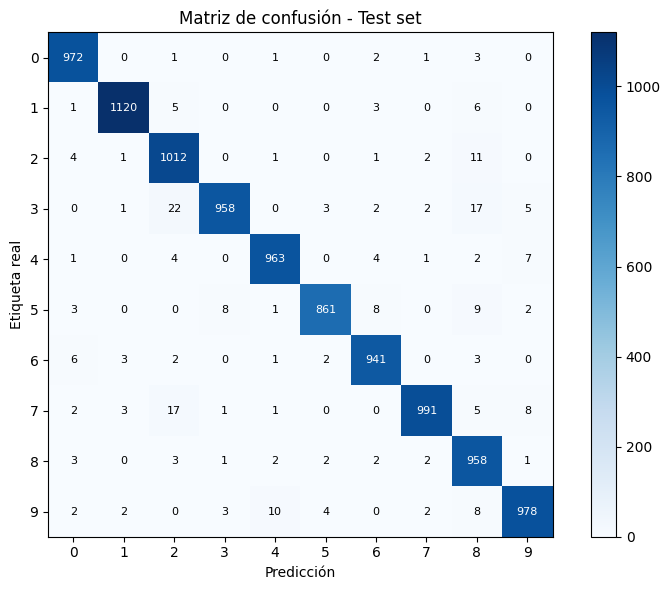

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Poner todas las predicciones y etiquetas en un arreglo
all_preds  = []
all_labels = []

best_model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = best_model(X_batch).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(y_batch)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()
n_classes  = 10

# Matriz de confusión 
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(all_labels, all_preds):
    conf_matrix[true, pred] += 1

# Métricas por clase 
precision = np.zeros(n_classes)
recall    = np.zeros(n_classes)
f1        = np.zeros(n_classes)

for i in range(n_classes):
    tp = conf_matrix[i, i]
    fp = conf_matrix[:, i].sum() - tp
    fn = conf_matrix[i, :].sum() - tp

    precision[i] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall[i]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1[i]        = (2 * precision[i] * recall[i] / (precision[i] + recall[i])
                    if (precision[i] + recall[i]) > 0 else 0.0)

accuracy_global = (all_preds == all_labels).mean()

# Impresión 
print(f"Accuracy global: {accuracy_global:.4f}\n")
print(f"{'Clase':>6} {'Precision':>10} {'Recall':>10} {'F1-score':>10}")
print("-" * 42)
for i in range(n_classes):
    print(f"{i:>6} {precision[i]:>10.4f} {recall[i]:>10.4f} {f1[i]:>10.4f}")

# Impresión de la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xlabel("Predicción")
ax.set_ylabel("Etiqueta real")
ax.set_title("Matriz de confusión - Test set")

for i in range(n_classes):
    for j in range(n_classes):
        color = "white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black"
        ax.text(j, i, conf_matrix[i, j], ha="center", va="center", color=color, fontsize=8)

plt.tight_layout()
plt.show()

## 7. Reflexiones personales

Como trabajo de introducción a redes neuronales debo decir que fue muy bueno. Aprendí a cómo construir la red neuronal y en qué parámetros o más bien, hiperparámetros me tengo que fijar al momento de elegir cómo quiero que sea la arquitectura de la red neuronal. Antes había trabajado con una red neuronal convolucional, pero realmente no me había parado a ver la teoría o el por qué de ciertas operaciones o líneas de código hacía.

En este trabajo, puedo decir que el flujo de cómo establecer, entrenar y evaluar una red neuronal, aunque sea una simple, me quedó claro, y también aprendí cómo funciona internamente cosas como el early stop que nunca lo hubiera hecho yo manualmente teniendo una librería. En cuanto a los resultados de los modelos, a mí en particular me sorpredió que el modelo 2 fuera el mejor. Yo pensaba que el 3, por tener más neuronas y capaz, iba a ser mejor. Pero otro aprendizaje que me llevo es que no necesariamente mayor profundidad significan mejores resultados, sino que también tienen que ver parámetros como el optimizador, o el learning rate que le moví para ese 3er modelo.